# Laboratory 8 Homework - Patryk Kożuch

## Dataset preparation

In [1]:
from itertools import batched

import polars as pl

df = pl.read_csv("images/metadata/images.csv.gz")

In [18]:
import os

BASE_DIR = "images/small/"

cleaned_df = (
    df.filter(
        (pl.col("height") >= 1000)
        & (pl.col("width") >= 1000)
        & (pl.col("path").map_elements(lambda x: os.path.exists(BASE_DIR + x), return_dtype=pl.Boolean))
    )
)

In [19]:
len(cleaned_df)

342878

## Model selection and Understanding

Questions:
1. `clip-ViT-B-32` embeds the images paired with text into a 512-dimensional space
2. Abbreviations:
    - `ViT` stands for Vision Transformer - the architecture of a model
    - `B` stands for Base - the size of the model (there are also `L` - Large size)
    - `32` stands for the size of the patches the image is split into (32x32 pixels)

## Database setup

In [20]:
from sqlalchemy.engine import URL

db_url = URL.create(
    drivername="postgresql+psycopg",
    username="postgres",
    password="password",
    host="localhost",
    port=5555,
    database="image_search_service"
)

In [23]:
from sqlalchemy import create_engine, Engine

engine = create_engine(db_url)

In [24]:
from sqlalchemy.orm import DeclarativeBase

class Base(DeclarativeBase):
    __abstract__ = True

In [28]:
from sqlalchemy.orm import Mapped, mapped_column
from pgvector.sqlalchemy import Vector

class Img(Base):
    __tablename__ = "images"
    __table_args__ = {'extend_existing': True}

    VECTOR_LENGTH: int = 512

    id: Mapped[int] = mapped_column(primary_key=True)
    image_path: Mapped[str] = mapped_column(nullable=False)
    embedding: Mapped[list[float]] = mapped_column(Vector(VECTOR_LENGTH), nullable=False)

## Image vectorization

In [48]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [69]:
from sqlalchemy.orm import Session
from sqlalchemy import Engine
import joblib
from PIL import Image
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm
from itertools import batched

MAX_IMAGES = 100_000
BATCH_SIZE = joblib.cpu_count(only_physical_cores=True)

def insert_images(engine: Engine, images):
    with Session(engine) as session:
        session.add_all(images)
        session.commit()

def vectorize_images(engine, model, image_paths):
    with tqdm(total=len(image_paths)) as pbar:
        for images_paths_batch in batched(image_paths, n=BATCH_SIZE):  # finish (suggestion - use `batched`)
            images = [Image.open(BASE_DIR + path) for path in images_paths_batch]

            # calculate embeddings

            embeddings = model.encode(images)

            # create Img instances for all images in batch
            imgs = [
                Img(
                    image_path=path,
                    embedding=embedding.tolist()
                )
                for path, embedding in zip(images_paths_batch, embeddings)
            ]

            # insert all batch images
            insert_images(engine, imgs)

            # update pbar
            pbar.update(len(imgs))

In [70]:
model = SentenceTransformer("clip-ViT-B-32", device=device)

In [71]:
from sqlalchemy import select
import matplotlib.pyplot as plt

class ImageSearch:
    def __init__(self, engine, model):
        self.engine = engine
        self.model = model

    def __call__(self, image_description: str, k: int):
        found_images = self.find_similar_images(image_description, k)
        self.display_images(found_images, k)

    def find_similar_images(self, image_description: str, k: int):
        image_embedding = self.model.encode(image_description)

        with Session(self.engine) as session:
            # remember about session and commit
            query = (
                select(Img)
                .order_by(Img.embedding.cosine_distance(image_embedding))
                .limit(k)
            )

            result = session.execute(query).scalars().all()
            imgs = [os.path.join(BASE_DIR, img.image_path) for img in result]

        return imgs

    def display_images(self, images, k):
        fig, axes = plt.subplots(1, k, figsize=(15, 5))

        for i, img_path in enumerate(images):
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].axis("off")
            axes[i].set_title(f"Image {i+1}")

        plt.show()

## Analysis

In [72]:
img = ImageSearch(engine, model)

In [86]:
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# Small dataset
image_paths = cleaned_df.select(pl.col("path").shuffle(seed=42)).to_series().to_list()[:500]
vectorize_images(engine, model, image_paths)

  0%|          | 0/500 [00:00<?, ?it/s]

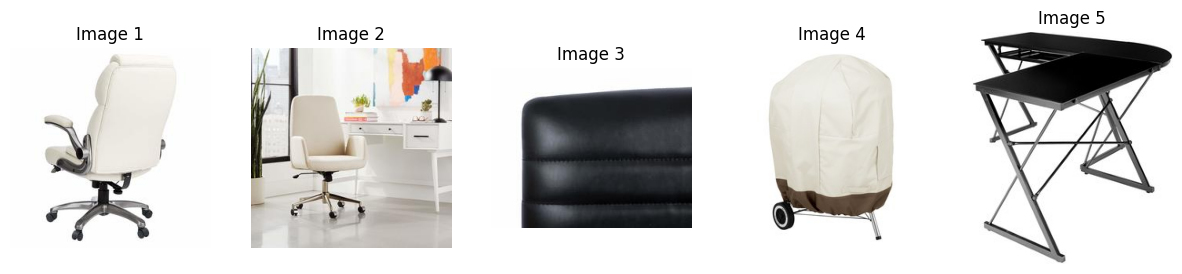

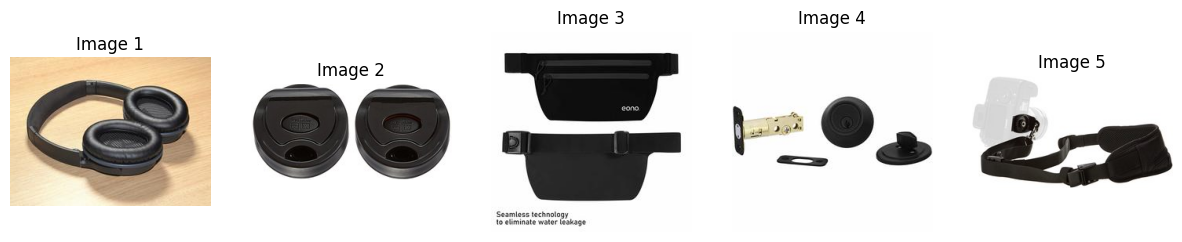

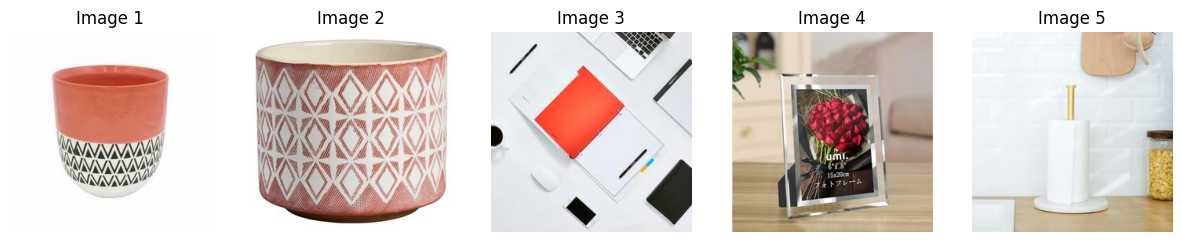

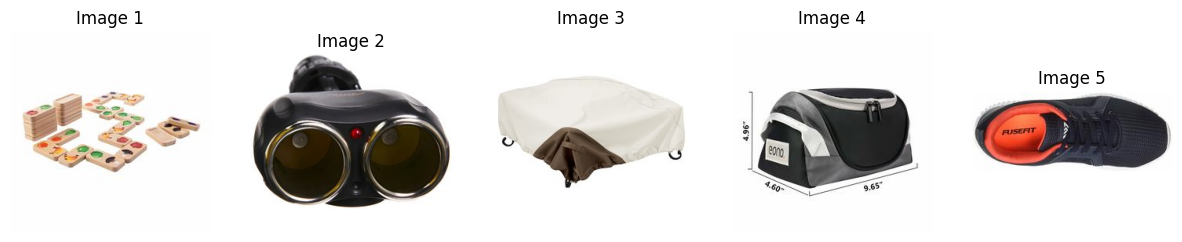

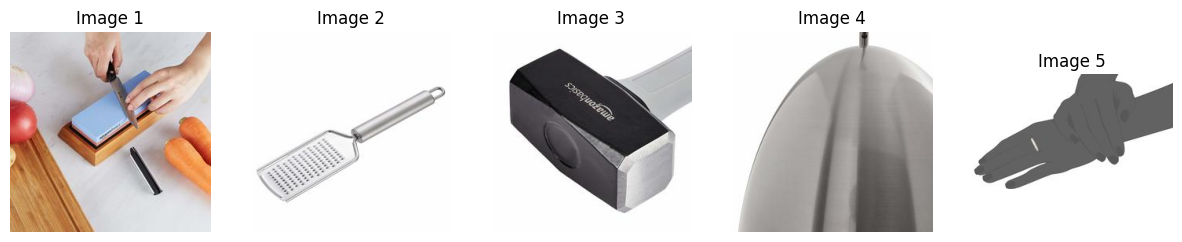

In [87]:
img("A black leather office chair with wheels", k=5)
img("Wireless bluetooth headphones", k=5)
img("Red coffee mug", k=5)
img("Children's toy car", k=5)
img("Stainless steel kitchen knife", k=5)

In [88]:
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# Medium dataset
image_paths = cleaned_df.select(pl.col("path").shuffle(seed=42)).to_series().to_list()[:10000]
vectorize_images(engine, model, image_paths)

  0%|          | 0/10000 [00:00<?, ?it/s]

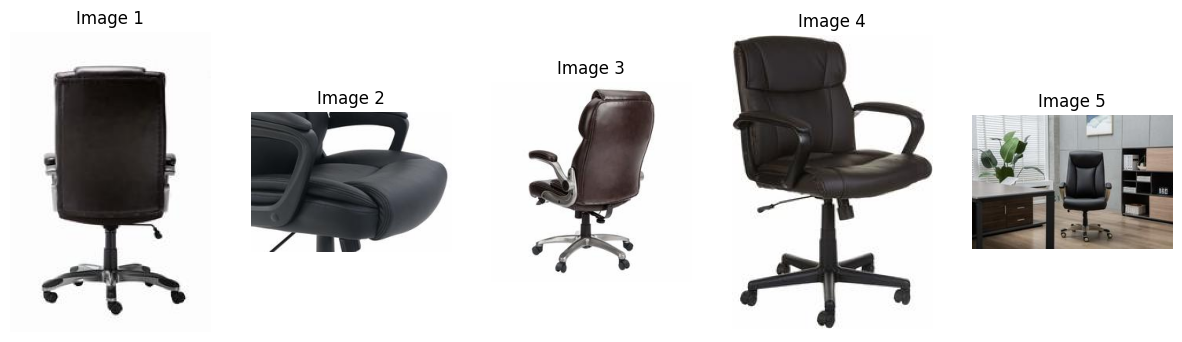

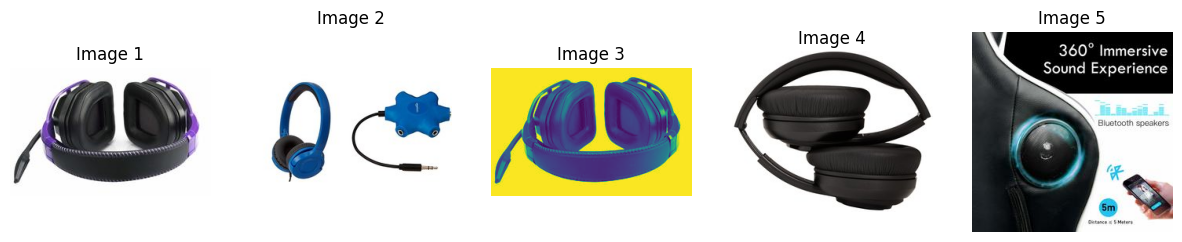

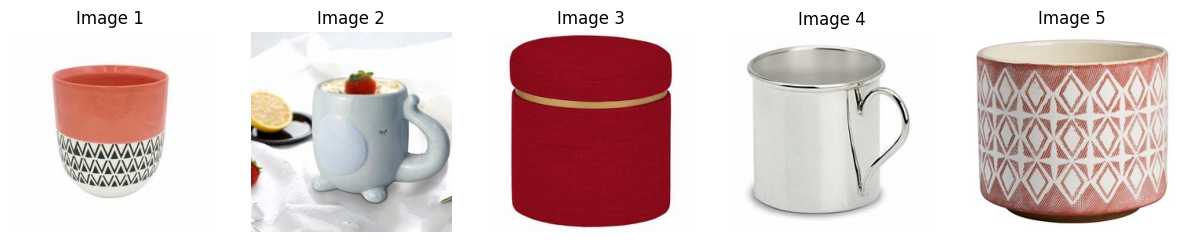

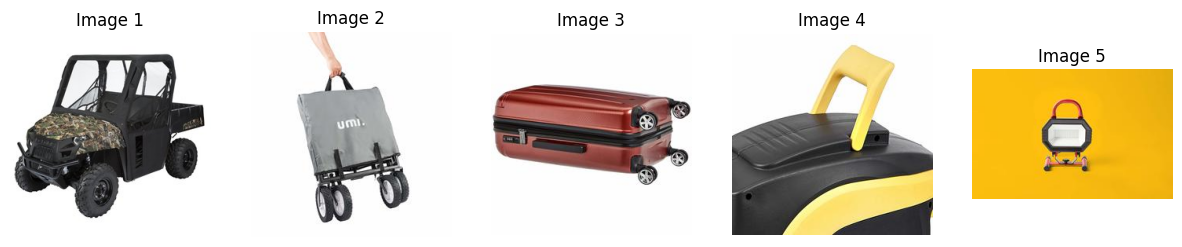

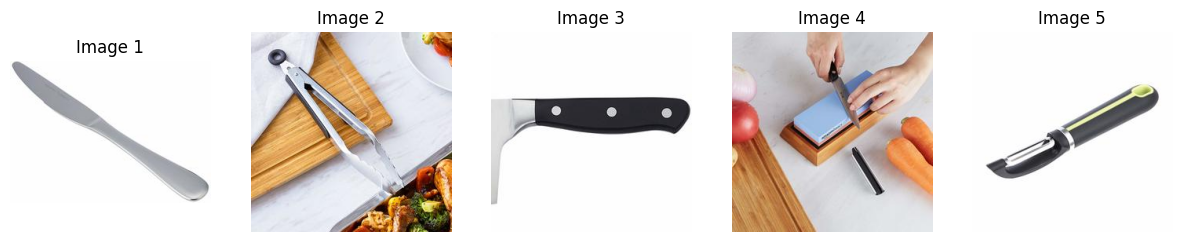

In [89]:
img("A black leather office chair with wheels", k=5)
img("Wireless bluetooth headphones", k=5)
img("Red coffee mug", k=5)
img("Children's toy car", k=5)
img("Stainless steel kitchen knife", k=5)

In [90]:
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# Large dataset
image_paths = cleaned_df.select(pl.col("path").shuffle(seed=42)).to_series().to_list()[:100000]
vectorize_images(engine, model, image_paths)

  0%|          | 0/100000 [00:00<?, ?it/s]

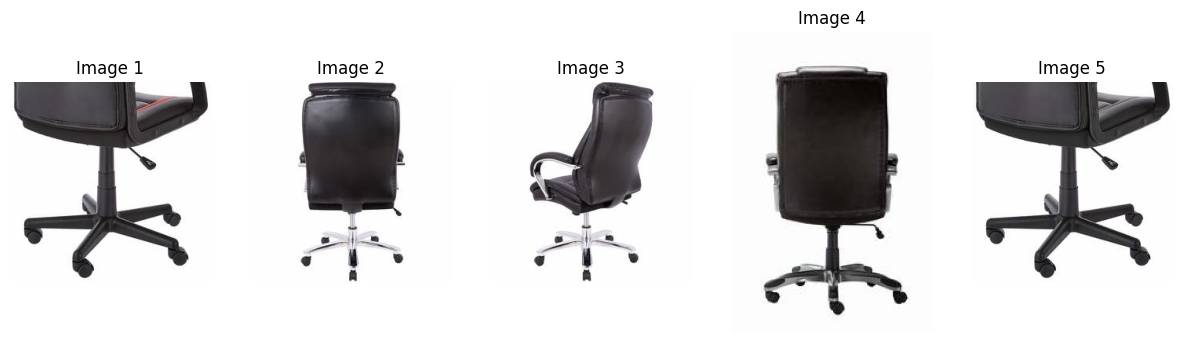

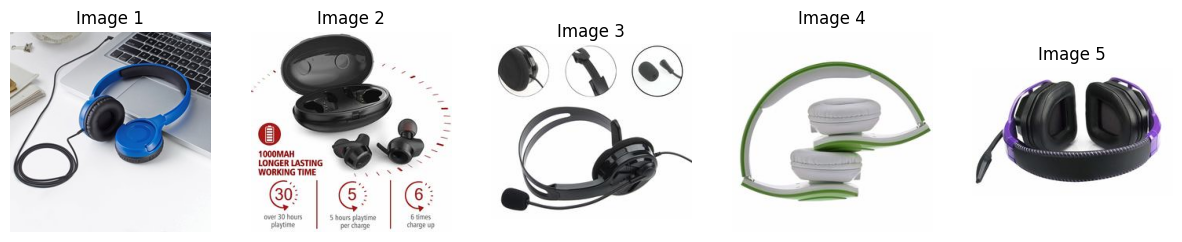

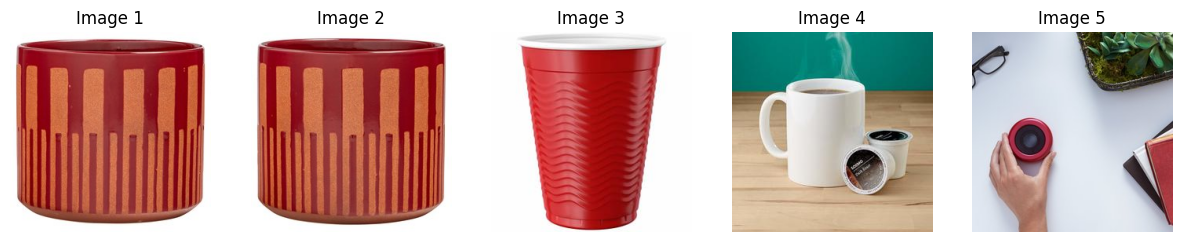

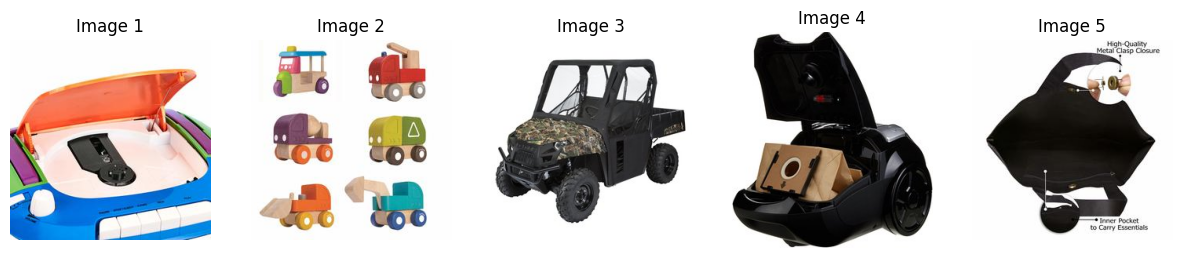

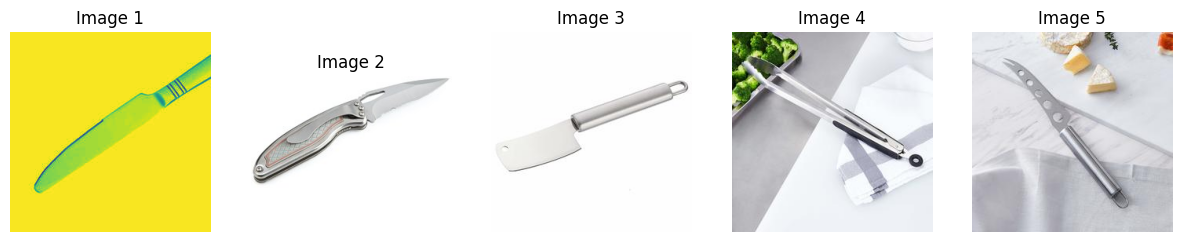

In [91]:
img("A black leather office chair with wheels", k=5)
img("Wireless bluetooth headphones", k=5)
img("Red coffee mug", k=5)
img("Children's toy car", k=5)
img("Stainless steel kitchen knife", k=5)

## Summary

Results are mostly relevant to the queries. In the smallest dataset, the quality is low due to the very limited dataset size. However, even in the smallest dataset, the results are somewhat related. E.g. instead of a *black* leather office chair, there are white ones - but still these are office chairs.

As the dataset size increases, the quality of results improves significantly. In the largest dataset, results are nearly perfect. Some of them are not exactly what was queried (e.g. vacuum cleaner instead of toy car), but they are still very similar in function or appearance.